In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"asmaulhusnaankhy","key":"4fcd096627d5e2a020d9d25664c77af4"}'}

In [ ]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d oddrationale/mnist-in-csv

Dataset URL: https://www.kaggle.com/datasets/oddrationale/mnist-in-csv
License(s): CC0-1.0
100% 15.2M/15.2M [00:01<00:00, 8.12MB/s]



In [ ]:
!unzip -q mnist-in-csv.zip

In [ ]:
import tensorflow  as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense , Flatten
from keras.applications.vgg16 import VGG16


Preparing the Dataset:
=

In [ ]:
from tensorflow.keras.datasets import mnist
import numpy as np
from tensorflow.keras.utils import to_categorical

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

train_images = np.stack([train_images] * 3, axis = -1)/255.0
test_images = np.stack([test_images] * 3, axis = -1)/255.0

train_images = tf.image.resize(tf.convert_to_tensor(train_images), [32, 32])
test_images = tf.image.resize(tf.convert_to_tensor(test_images), [32, 32])

train_labels = to_categorical(train_labels, 10)
test_labels = to_categorical(test_labels, 10)

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Input, GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    weights = 'imagenet',
    include_top = False,
    input_shape = (32, 32, 3)
)




/tmp/ipykernel_613/2303349882.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
base_model.trainable = False

In [ ]:
inputs = Input(shape = (32, 32, 3))
x = base_model(inputs, training = False)
x = GlobalAveragePooling2D()(x)
outputs = Dense(10, activation = 'softmax')(x)
model = Model(inputs, outputs)

In [ ]:
model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])


In [ ]:
history = model.fit(train_images, train_labels, epochs = 10, validation_split = 0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 39s 11ms/step - accuracy: 0.5282 - loss: 1.5999 - val_accuracy: 0.6031 - val_loss: 1.3011
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.6173 - loss: 1.2228 - val_accuracy: 0.6378 - val_loss: 1.1409
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.6391 - loss: 1.1195 - val_accuracy: 0.6526 - val_loss: 1.0734
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6504 - loss: 1.0695 - val_accuracy: 0.6603 - val_loss: 1.0371
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.6568 - loss: 1.0403 - val_accuracy: 0.6639 - val_loss: 1.0149
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.6606 - loss: 1.0212 - val_accuracy: 0.6665 - val_loss: 1.0011
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.6628 - loss: 1.0082 - val_accuracy: 0.6708 - val_loss: 0.9910
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6650 - loss: 

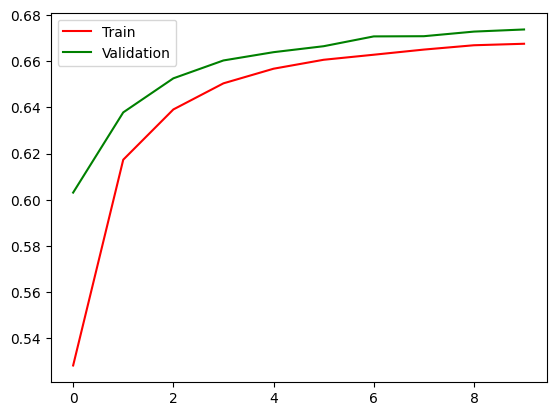

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], color = 'red', label = 'Train')
plt.plot(history.history['val_accuracy'], color = 'green', label = 'Validation')
plt.legend()
plt.show()

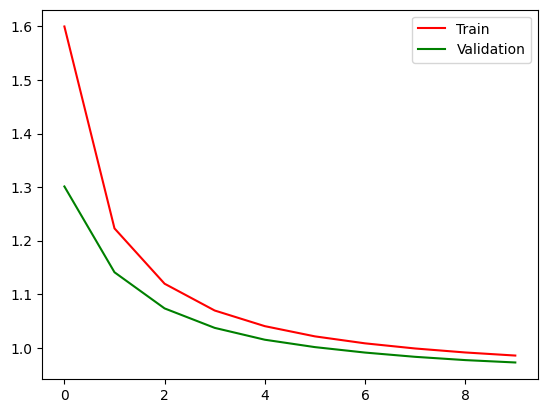

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], color = 'red', label = 'Train')
plt.plot(history.history['val_loss'], color = 'green', label = 'Validation')
plt.legend()
plt.show()